In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [30]:
device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print(device)

cpu


In [31]:
X,y = make_moons(n_samples = 1000,noise = 0.1, random_state = 42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [32]:
print(X_train.shape,X_test.shape)

(800, 2) (200, 2)


[]

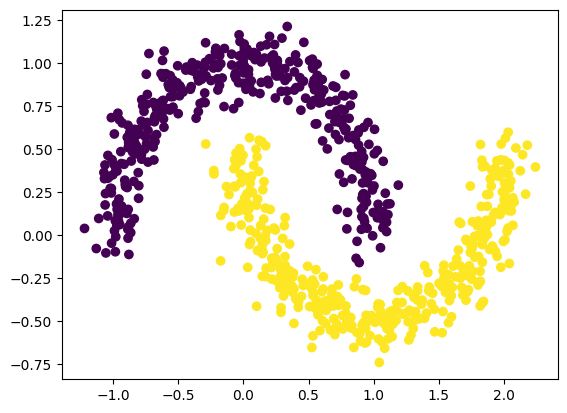

In [40]:
plt.scatter(X_train[:,[0]],X_train[:,[1]],c = y_train,cmap = 'viridis')
plt.plot()

In [44]:
X_train_t = torch.tensor(X_train, dtype = torch.float32).to(device)
X_test_t = torch.tensor(X_test,dtype = torch.float32).to(device)

In [79]:
y_train_t = torch.tensor(y_train,dtype = torch.float32).reshape(-1,1).to(device)
y_test_t = torch.tensor(y_test,dtype = torch.float32).reshape(-1,1).to(device)

print(y_train_t.shape)

torch.Size([800, 1])


In [67]:
class MoonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features = 2,out_features = 16)
        self.layer2 = nn.Linear(in_features = 16,out_features = 16)
        self.output_layer = nn.Linear(in_features = 16,out_features = 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

In [68]:
model = MoonClassifier().to(device)
print(model)

MoonClassifier(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [69]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr = 0.01, weight_decay = 0.001)

------Start Training------
Epoch 20 ||  Loss: 0.4062117636203766
Epoch 40 ||  Loss: 0.22240135073661804
Epoch 60 ||  Loss: 0.16159866750240326
Epoch 80 ||  Loss: 0.08830737322568893
Epoch 100 ||  Loss: 0.026319555938243866


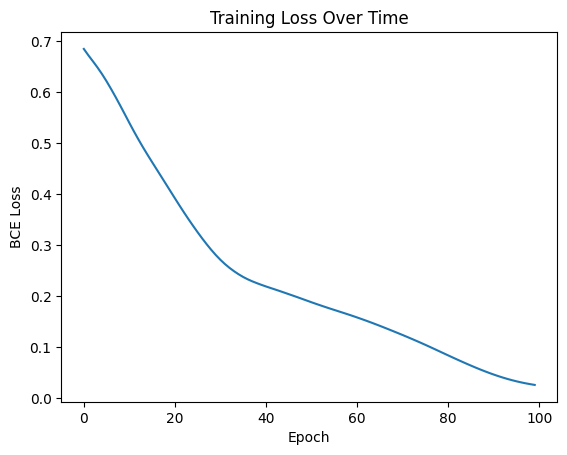

In [70]:
epochs = 100
loss_history = []

print('------Start Training------')

for epoch in range(epochs):
    model.train()
    predictions = model(X_train_t)
    loss = criterion(predictions,y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if (epoch+1)%20==0:
        print(f'Epoch {epoch+ 1} ||  Loss: {loss.item()}')


plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.show()

In [106]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    test_preds_label = torch.round(test_preds)
    correct = (test_preds_label == y_test_t).sum().item()

    accuracy = correct / len(y_test_t)

print(f"Accuracy Test on non-Linear Data : {100*accuracy:.2f}")

Accuracy Test on non-Linear Data : 100.00
